In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('expert_dataset.csv')
print(df.head)

<bound method NDFrame.head of               category      lat       lon  \
0      Known PFAS user  52.5041 -0.682637   
1      Known PFAS user  50.8719  6.034520   
2      Known PFAS user  50.2234  8.765600   
3      Known PFAS user  47.8586  5.347160   
4      Known PFAS user  39.4717 -0.538828   
...                ...      ...       ...   
44583            Known  51.2326  4.335670   
44584            Known  51.2302  4.337570   
44585            Known  51.3153  4.346180   
44586            Known  51.2343  4.334540   
44587            Known  51.2326  4.335070   

                                      name         city         country  \
0                                       3F        Corby  United Kingdom   
1                                       3M     Kerkrade     Netherlands   
2       3P - Performance Plastics Products       Karben         Germany   
3         3P Performance Plastics Products      Langres          France   
4      3P Productos Plásticos Performantes     Valenci

In [2]:
# Display all unique values in the 'matrix' column
print(df['name'].unique())

['3F' '3M' '3P - Performance Plastics Products' ... 'F5'
 'Fratta-Gorzone VALLE Collettore ARICA' 'Scarico della Miteni']


In [3]:
# Cleaning data 
df_clean = df.drop(columns=['pfas_sum', 'source_type', 'source_url', 'details', ])

In [4]:
# Display all unique values in the 'matrix' column
print(df['matrix'].unique())

[nan 'Drinking water' 'Wastewater' 'Unknown' 'Groundwater' 'Soil'
 'Surface water' 'Sediment' 'Biota' 'Sea water' 'Septage' 'Sludge'
 'Leachate']


In [5]:
# setting up the data
from sklearn.neighbors import KNeighborsRegressor
import numpy as np
import pandas as pd

# Columns to estimate
pfas_cols = ['pfos', 'pfoa', 'pfos_pfoa', 'pfna', 'pfbs', 'pfhxa', 'pfhxs']

# Choose matrix type
selected_matrix = "Groundwater"  
# Choose cordinate set
your_lat = 57.7381
your_lon = 10.5678

new_coords = np.array([[your_lat, your_lon]])


# Filter by matrix and drop rows missing required values
df_valid = df_clean[
    (df['matrix'] == selected_matrix)
].dropna(subset=['lat', 'lon'] + pfas_cols, how='any')

# Features: latitude and longitude
X = df_valid[['lat', 'lon']].values

# Targets: multiple PFAS columns
y = df_valid[pfas_cols].values



In [6]:
# remove outliers above the 95th percentile for each PFAS column
for col in pfas_cols:
    threshold = df[col].quantile(0.95)
    df = df[df[col] <= threshold]

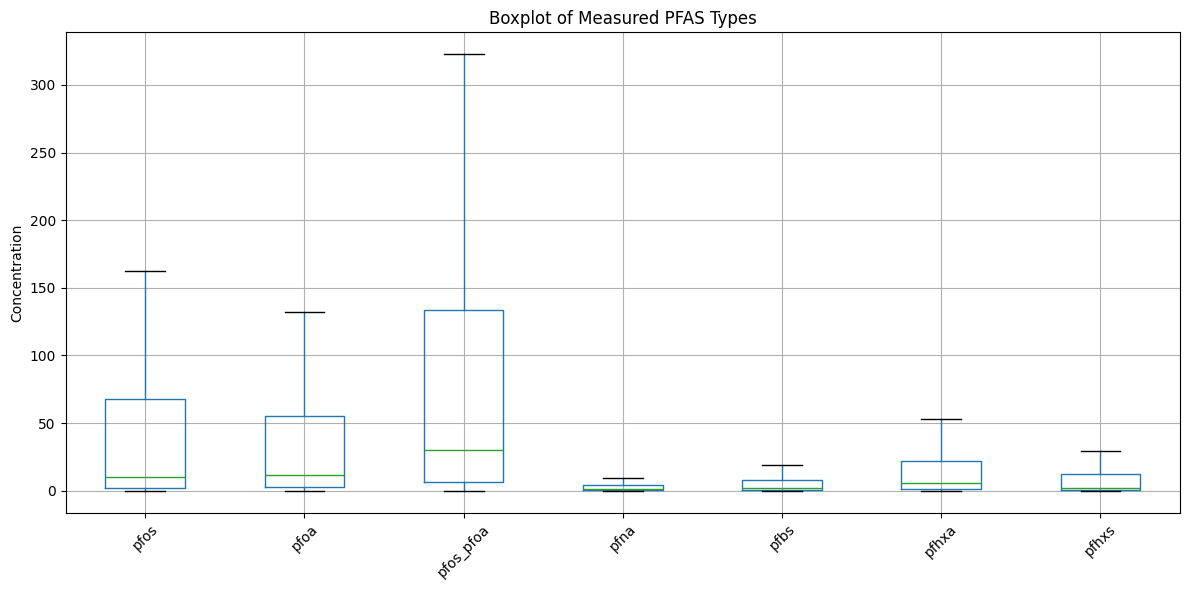

In [7]:
# Select only the columns of interest and drop rows where all are NaN
pfas_cols = ['pfos', 'pfoa', 'pfos_pfoa', 'pfna', 'pfbs', 'pfhxa', 'pfhxs']
df_box = df[pfas_cols].dropna(how='all')

# Create a boxplot for the selected PFAS types
plt.figure(figsize=(12, 6))
df_box.boxplot(column=pfas_cols, showfliers=False)
plt.ylabel('Concentration')
plt.title('Boxplot of Measured PFAS Types')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

def split_data(X, y, test_size=0.2, random_state=42):
    """Splits features and targets (y should be log-transformed here)."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, shuffle=True
    )
    return X_train, X_test, y_train, y_test

def calculate_evaluation_metrics(y_true, y_pred, target_names):
    """Calculates R2 by comparing RAW (untransformed) values."""
    if y_true.shape != y_pred.shape:
        raise ValueError("y_true and y_pred must have the same shape.")
    
    r2_scores = [r2_score(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])]
    mean_concentrations = np.mean(y_true, axis=0)
    
    results_df = pd.DataFrame({
        'Target': target_names,
        'R2 Score': r2_scores,
        'Mean Concentration (y_true)': mean_concentrations
    })
    
    return results_df.set_index('Target')

def inverse_transform_predictions(y_pred_log):
    """Applies the inverse transformation: exp(x) - 1."""
    y_pred_raw = np.expm1(y_pred_log)
    y_pred_raw[y_pred_raw < 0] = 0 
    return y_pred_raw

def transform_targets(y_raw):
    """Applies a log-transformation: log(1 + x)."""
    y_transformed = np.log1p(y_raw)
    return y_transformed.values

def calculate_evaluation_metrics(y_true, y_pred, target_names):
    """Calculates R2, MAE, and RMSE by comparing RAW values."""
    if y_true.shape != y_pred.shape:
        raise ValueError("y_true and y_pred must have the same shape.")
    
    r2_scores = [r2_score(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])]
    maes = [mean_absolute_error(y_true[:, i], y_pred[:, i]) for i in range(y_true.shape[1])]
    rmses = [np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i])) for i in range(y_true.shape[1])]
    mean_concentrations = np.mean(y_true, axis=0)
    
    results_df = pd.DataFrame({
        'Target': target_names,
        'R2 Score': r2_scores,
        'MAE (Raw Scale)': maes,
        'RMSE (Raw Scale)': rmses,
        'Mean Concentration (y_true)': mean_concentrations
    })
    
    return results_df.set_index('Target')

Scaling the data

In [9]:
X_train, X_test, y_train, y_test = split_data(X, y)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# log-transform the target arrays
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [10]:
#Define and train KNN Regressor
knn_model = KNeighborsRegressor(n_neighbors=3, weights='distance')
knn_model.fit(X_train_scaled, y_train_log)

y_pred_log_knn = knn_model.predict(X_test_scaled)


print("\nSTEP 3: Inverse Transform and Evaluate")

# INVERSE TRANSFORM predictions back to the original (raw) concentration scale
y_pred_raw_knn = inverse_transform_predictions(y_pred_log_knn)

y_test = inverse_transform_predictions(y_test_log)


# Calculate metrics: Compare y_test_raw (True values) vs y_pred_raw_knn (Predictions)
knn_evaluation_results = calculate_evaluation_metrics(y_test, y_pred_raw_knn, pfas_cols)

print("--- KNN EVALUATION RESULTS (n=3, distance weighting) ---")
print(knn_evaluation_results)


# Predict at new coordinates
# Scale new coordinates
new_coords_scaled = scaler.transform(new_coords)
pred_new_log = knn_model.predict(new_coords_scaled)
pred_new = inverse_transform_predictions(pred_new_log)
print("\nPredicted PFAS at your coordinates:")
print(pd.DataFrame(pred_new, columns=pfas_cols))
evaluation_results = calculate_evaluation_metrics(y_test, y_pred_raw_knn, pfas_cols)
print(evaluation_results)



STEP 3: Inverse Transform and Evaluate
--- KNN EVALUATION RESULTS (n=3, distance weighting) ---
           R2 Score  MAE (Raw Scale)  RMSE (Raw Scale)  \
Target                                                   
pfos       0.050870      2200.426909       8722.018302   
pfoa       0.348900      1116.261712       5237.262372   
pfos_pfoa  0.191937      3244.370867      10593.591068   
pfna       0.016674        38.062775        172.011890   
pfbs       0.047781      3283.778267      34519.097435   
pfhxa      0.219482      1513.455674       9709.433379   
pfhxs      0.432332      3032.422111      23569.460183   

           Mean Concentration (y_true)  
Target                                  
pfos                       2540.508129  
pfoa                       1635.784581  
pfos_pfoa                  4176.292710  
pfna                         42.951032  
pfbs                       3576.052323  
pfhxa                      1907.363613  
pfhxs                      3275.885871  

Predicted 

In [11]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Configure Gradient Boosting (wrapped for multi-output)
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=42
)
gbr_multi = MultiOutputRegressor(gbr)

gbr_multi.fit(X_train_scaled, y_train)

y_pred = gbr_multi.predict(X_test_scaled)
mae_per_target = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
rmse_per_target = (mean_squared_error(y_test, y_pred, multioutput='raw_values')) ** 0.5

evaluation_results = calculate_evaluation_metrics(y_test, y_pred, pfas_cols)
print(evaluation_results)

print("Gradient Boosting - MAE per PFAS:")
print(pd.Series(mae_per_target, index=pfas_cols))
print("\nGradient Boosting - RMSE per PFAS:")
print(pd.Series(rmse_per_target, index=pfas_cols))
print(f"\nOverall MAE: {mean_absolute_error(y_test, y_pred):.3f}")
print(f"Overall RMSE: {(mean_squared_error(y_test, y_pred) ** 0.5):.3f}")


# Predict PFAS at the new coordinates (uses scaler if available)
new_scaled = scaler.transform(new_coords) if 'scaler' in globals() else new_coords
pred_new = gbr_multi.predict(new_scaled)
print("\nPredicted PFAS at your coordinates:")
print(pd.DataFrame(pred_new, columns=pfas_cols))

evaluation_results = calculate_evaluation_metrics(y_test, y_pred, pfas_cols)
print(evaluation_results)

           R2 Score  MAE (Raw Scale)  RMSE (Raw Scale)  \
Target                                                   
pfos      -0.033979      2833.970198       9103.534568   
pfoa       0.646458      1312.120647       3859.232583   
pfos_pfoa  0.266762      3674.770613      10091.206956   
pfna      -0.121535        46.322465        183.702986   
pfbs       0.097529      3492.778315      33605.289180   
pfhxa      0.281229      1860.102280       9317.465850   
pfhxs      0.188807      4545.275920      28175.032605   

           Mean Concentration (y_true)  
Target                                  
pfos                       2540.508129  
pfoa                       1635.784581  
pfos_pfoa                  4176.292710  
pfna                         42.951032  
pfbs                       3576.052323  
pfhxa                      1907.363613  
pfhxs                      3275.885871  
Gradient Boosting - MAE per PFAS:
pfos         2833.970198
pfoa         1312.120647
pfos_pfoa    3674.770613